# 🛰️ Phase 5 — UAV Flight Planning & Aerial Disease Heatmaps

1. **Camera optics:** ground sampling distance and footprint per capture.
2. **Mission planner:** boustrophedon survey waypoints over a farm polygon.
3. **Heatmaps:** interactive and static maps from patch predictions.

> **Two things this notebook does not show.** The patch predictions below
> are **synthetic** (`make_demo_predictions`), generated so the mapping code
> can be demonstrated without an orthomosaic; they are not measurements of
> any field. And the classifier the real pipeline applies is the **leaf**
> model, trained and evaluated on close-up photographs and never evaluated
> on imagery taken from altitude. A UAV heatmap is a scouting aid for
> deciding where to walk, not a diagnosis of the plants it colours.
>
> To run the pipeline on real imagery:
>
> ```bash
> python -m src.phase5_uav.patch_runner --image <orthomosaic.tif> \
>     --output data/uav/patch_predictions.csv
> python -m src.phase5_uav.heatmap --csv data/uav/patch_predictions.csv \
>     --output data/uav/disease_heatmap.html
> ```


In [1]:
# Setup & Imports
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import matplotlib.pyplot as plt
from PIL import Image

from src.phase5_uav.flight_planner import Camera, generate_grid
from src.phase5_uav.heatmap import (
    CLASS_INFO,
    make_demo_predictions,
    build_folium_map,
    build_static_map,
    build_summary,
    print_summary,
)

print("✅ UAV Flight Planner & Heatmap modules loaded!")


✅ UAV Flight Planner & Heatmap modules loaded!


### 1. Drone Optics & Flight Mission Planning

In [2]:
# Define farm polygon boundary
farm_polygon = [
    (3.9450, 7.3760),
    (3.9495, 7.3762),
    (3.9490, 7.3795),
    (3.9445, 7.3792),
    (3.9450, 7.3760),
]

camera = Camera(
    sensor_width_mm=6.17,
    sensor_height_mm=4.55,
    focal_length_mm=3.6,
    image_width_px=4000,
    image_height_px=3000,
)

altitude_m = 30.0
overlap_pct = 75.0
sidelap_pct = 65.0

waypoints = generate_grid(
    coords=farm_polygon,
    altitude_m=altitude_m,
    overlap_pct=overlap_pct,
    sidelap_pct=sidelap_pct,
    camera=camera,
)

print(f"Generated Waypoints: {len(waypoints)} points")
print(f"GSD at {altitude_m}m: {camera.gsd_cm(altitude_m):.2f} cm/pixel")
fw, fh = camera.footprint_m(altitude_m)
print(f"Camera Ground Footprint: {fw:.1f}m width x {fh:.1f}m height")


Generated Waypoints: 1364 points
GSD at 30.0m: 1.29 cm/pixel
Camera Ground Footprint: 51.4m width x 37.9m height


In [3]:
# Visualize Boustrophedon Flight Trajectory
poly_lons = [c[0] for c in farm_polygon]
poly_lats = [c[1] for c in farm_polygon]
wp_lons = [w.lon for w in waypoints]
wp_lats = [w.lat for w in waypoints]

plt.figure(figsize=(10, 8))
plt.fill(poly_lons, poly_lats, color="#2ecc71", alpha=0.15, label="Farm Boundary")
plt.plot(poly_lons, poly_lats, color="#27ae60", linewidth=2.5, linestyle="--")

plt.plot(wp_lons, wp_lats, color="#2980b9", linewidth=1.5, marker="o", markersize=4, label="Drone Waypoints")
plt.scatter(wp_lons[0], wp_lats[0], color="#27ae60", s=130, zorder=5, label="Takeoff")
plt.scatter(wp_lons[-1], wp_lats[-1], color="#e74c3c", s=130, zorder=5, label="Return-to-Home")

for i in range(0, len(waypoints) - 1, max(1, len(waypoints) // 12)):
    dx = wp_lons[i+1] - wp_lons[i]
    dy = wp_lats[i+1] - wp_lats[i]
    plt.arrow(wp_lons[i], wp_lats[i], dx * 0.5, dy * 0.5,
              head_width=0.00012, head_length=0.00015, fc="#2980b9", ec="#2980b9", zorder=4)

plt.title("MaizeGuard UAV — Autonomous Scouting Mission", fontsize=13, pad=12)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


<Figure size 1000x800 with 1 Axes>

### 2. Interactive Folium Satellite Disease Heatmap

In [4]:
# Synthetic predictions: this demonstrates the mapping code, not a survey.
# Generate aerial patch predictions and build interactive Folium satellite map
demo_preds = make_demo_predictions(n=250)
html_file = "data/uav/disease_heatmap.html"
m = build_folium_map(demo_preds, output_html=html_file)

summary = build_summary(demo_preds, output_json="data/uav/heatmap_summary.json")
print_summary(summary)

# Display interactive Leaflet map inline!
m

print(f"\nSynthetic rows: {sum(1 for p in demo_preds if p.get('synthetic'))}"
      f" of {len(demo_preds)} — none of these numbers were measured.")


Interactive map saved: data/uav/disease_heatmap.html
Summary JSON saved: data/uav/heatmap_summary.json

──── UAV survey summary ─────────────────────────────
  Total patches analysed : 250
  Disease patches        : 145  (58.0%)
  Avg inference latency  : not recorded

  NCLB       48 ( 19.2%)  █████████
  Rust       59 ( 23.6%)  ███████████
  GLS        38 ( 15.2%)  ███████
  Healthy   105 ( 42.0%)  █████████████████████

  Recommendation: 58% of field affected. Dominant: Rust. Apply triazole fungicide (propiconazole) early. Rust spreads rapidly in cool humid conditions.
─────────────────────────────────────────────────────


Synthetic rows: 250 of 250 — none of these numbers were measured.


### 3. Static Agronomy Field Report

Static map saved: data/uav/disease_heatmap.png


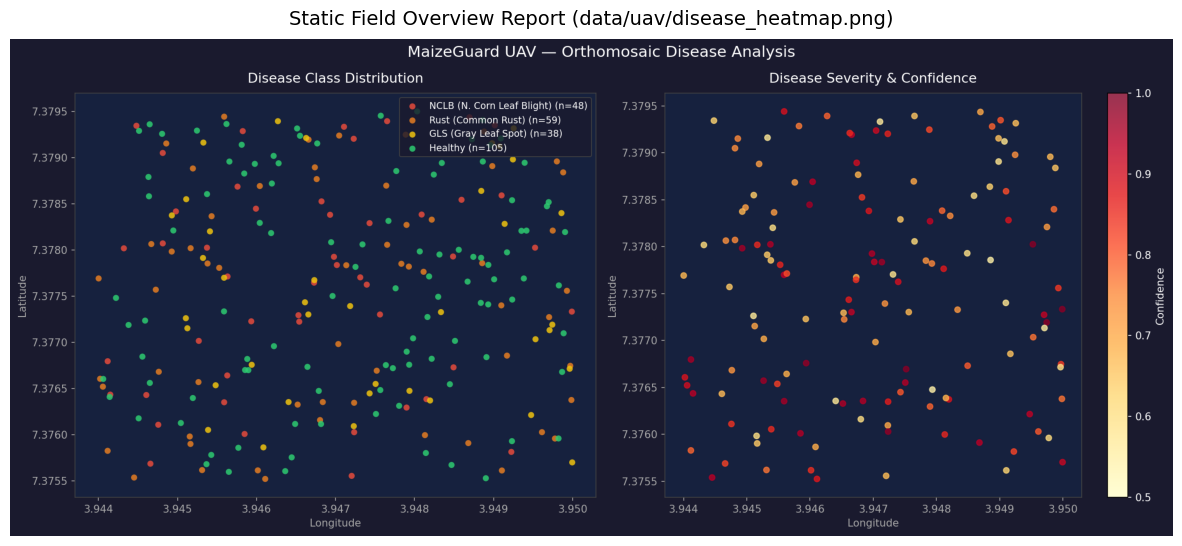

In [5]:
# Generate and display static overview figure
png_file = "data/uav/disease_heatmap.png"
build_static_map(demo_preds, output_png=png_file)

report_img = Image.open(png_file)
plt.figure(figsize=(15, 6.5))
plt.imshow(report_img)
plt.axis("off")
plt.title("Static Field Overview Report (data/uav/disease_heatmap.png)", fontsize=14, pad=10)
plt.show()
